# 08 · Power, sizing & decisions — the bookends of every experiment

**NB 08.** Like NB 07, a **cross-cutting layer**, not a design — it wraps **every** experiment at both
ends: **DRAFT** (how big must this be? — the power-gate) and **DECIDED** (do we ship? — the decision
rule). We build, by hand:
1. **power & MDE** — the closed-form sample size (Confidence SSC), cross-checked against
   **simulation-based power** (the harness — the *only* honest way for switchback/clustered designs);
2. the **DRAFT power-gate** — multiple-testing + guardrail corrections; the platform refuses an
   underpowered design;
3. **test-and-roll** — profit-maximizing sizing (test small, roll the winner) — far smaller than NHST;
4. the **decision rule** — ship = **OEC superiority AND every guardrail non-inferior** (a guardrail
   regression blocks the ship even if the primary moves), with the trade-off vector Λ.

Then we **promote** to `lyra/{power,decisions}.py` and wire both ends into the chassis. Backs:
`papers/sample-size-calculation.md` (SSC), Feit–Berman 2019 (test-and-roll), Ng–Imbens 2026 /
Schultzberg et al 2024 (decision rule), `papers/platform-engineering.md`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))

import nbtools; nbtools.set_style()
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY

## 1. Power, MDE & the honest cross-check

The two-sample sample size (balanced, binary): with absolute effect $\Delta=\mu\cdot\text{relMDE}$ and
$\sigma^2=\mu(1-\mu)$,
$$N=\frac{4\,(z_{1-\alpha}+z_{\text{power}})^2\,\sigma^2}{\Delta^2}.$$
**Power** is just "simulate under $H_1$, count rejections" — so the closed form must agree with a
Monte-Carlo. We verify it (and this *simulation-based power* is the only honest route for designs with
no closed form — switchback, clustered).

closed-form required N = 50,233 (25,116/arm) for an MDE of 0.010 (5% rel) at 80% power
simulation-based power at that N = 0.80  (≈ 0.80 ✓ — the formula is honest)


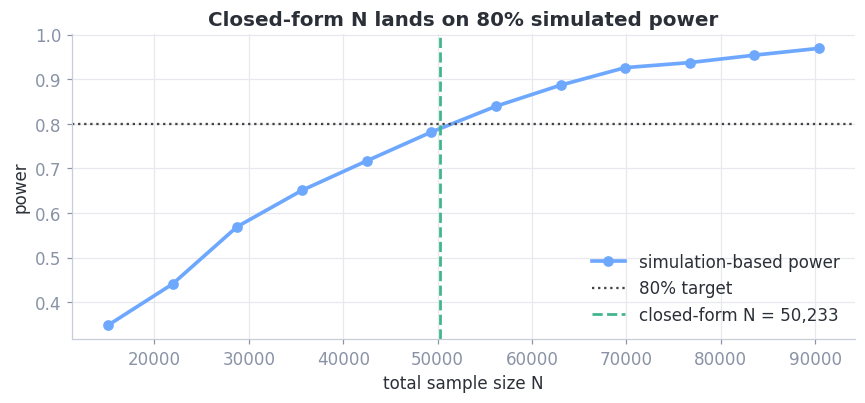

In [2]:
def required_n(mu, rel_mde, alpha=0.05, power=0.8):
    sigma2 = mu * (1 - mu); z = norm.ppf(1 - alpha / 2) + norm.ppf(power)   # two-sided → z_{1-α/2}
    return int(round(4 * z ** 2 * sigma2 / (mu * rel_mde) ** 2))

def sim_power(n_per_arm, p0, delta, R=3000, seed0=0):
    rng = np.random.default_rng(seed0); rej = 0
    for r in range(R):
        c = rng.binomial(n_per_arm, p0); t = rng.binomial(n_per_arm, p0 + delta)
        p0h, p1h = c / n_per_arm, t / n_per_arm
        se = math.sqrt(p0h * (1 - p0h) / n_per_arm + p1h * (1 - p1h) / n_per_arm)
        rej += abs(p1h - p0h) / se > 1.959964 if se > 0 else 0
    return rej / R

p0, rel_mde = 0.20, 0.05; delta = p0 * rel_mde
N = required_n(p0, rel_mde); per_arm = N // 2
print(f"closed-form required N = {N:,} ({per_arm:,}/arm) for an MDE of {delta:.3f} (5% rel) at 80% power")
print(f"simulation-based power at that N = {sim_power(per_arm, p0, delta):.2f}  (≈ 0.80 ✓ — the formula is honest)")

# power curve from simulation, with the required N marked
ns = np.linspace(per_arm * 0.3, per_arm * 1.8, 12).astype(int)
pw = [sim_power(n, p0, delta, R=1500) for n in ns]
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(2 * ns, pw, "-o", color=BLUE, lw=2.4, label="simulation-based power")
ax.axhline(0.8, color="#444", ls=":", label="80% target"); ax.axvline(N, color=GREEN, ls="--", lw=1.8, label=f"closed-form N = {N:,}")
ax.set_xlabel("total sample size N"); ax.set_ylabel("power"); ax.set_title("Closed-form N lands on 80% simulated power")
ax.legend(); plt.tight_layout(); plt.show()

## 2. The DRAFT power-gate — corrections that change N

Real experiments test several metrics. **Multiple testing** splits α across *success* metrics
($\alpha_{adj}=\alpha/(C\cdot S)$); **guardrails with non-inferiority margins** need higher per-metric
power ($\text{power}_{adj}=1-\frac{1-\text{power}}{G_{\text{NIM}}+\min(S,1)}$). Both **inflate N**. The
gate **refuses** a design whose available traffic is below the required N.

In [3]:
def required_n_full(mu, rel_mde, alpha=0.05, power=0.8, C=1, S=1, G_nim=0):
    a = alpha / (C * max(S, 1)); p = 1 - (1 - power) / (G_nim + max(min(S, 1), 1))
    z = norm.ppf(1 - a / 2) + norm.ppf(p); sigma2 = mu * (1 - mu)        # two-sided
    return int(round(4 * z ** 2 * sigma2 / (mu * rel_mde) ** 2))

for (C, S, G) in [(1, 1, 0), (1, 2, 0), (2, 1, 0), (1, 2, 4)]:
    print(f"  comparisons={C}, success={S}, guardrails-NIM={G}:  N = {required_n_full(p0, rel_mde, C=C, S=S, G_nim=G):,}")
print(f"\ngate: available 18,000 vs required {required_n_full(p0, rel_mde, S=2, G_nim=4):,}  →  "
      f"{'OK' if 18000 >= required_n_full(p0, rel_mde, S=2, G_nim=4) else 'UNDERPOWERED (refuse / extend)'}")

  comparisons=1, success=1, guardrails-NIM=0:  N = 50,233
  comparisons=1, success=2, guardrails-NIM=0:  N = 60,832
  comparisons=2, success=1, guardrails-NIM=0:  N = 60,832
  comparisons=1, success=2, guardrails-NIM=4:  N = 101,995

gate: available 18,000 vs required 101,995  →  UNDERPOWERED (refuse / extend)


## 3. Test-and-roll — size for *profit*, not significance

NHST sizing asks "how many to be *sure*?" Feit–Berman (2019) ask "how many to **maximize total
reward**?" — test on a small slice, then **roll the winner** to the rest. With two arms, population $N$,
outcome SD $\sigma$ and prior SD $s$, the optimal test size is
$$n^\*=\sqrt{\tfrac{N}{4}\big(3r^2+4r\big)+\big(\tfrac{3r}{4}\big)^2}-\tfrac{3r}{4},\quad r=(s/\sigma)^2,$$
typically **far smaller** than the NHST $N$ — you accept more false positives but capture small wins fast.

In [4]:
def test_and_roll(N, sigma, s):
    r = (s / sigma) ** 2
    return int(round(math.sqrt(N / 4 * (3 * r ** 2 + 4 * r) + (3 * r / 4) ** 2) - 3 * r / 4))

N_pop, sigma, s = 200_000, math.sqrt(p0 * (1 - p0)), 0.05
n_tr = test_and_roll(N_pop, sigma, s)
print(f"population N = {N_pop:,}")
print(f"  NHST per-arm test size      : {per_arm:,}  (size for significance)")
print(f"  test-and-roll per-arm size  : {n_tr:,}  (size for profit — test small, roll the winner)")
print(f"  → test-and-roll tests ~{per_arm / n_tr:.0f}× fewer users per arm; the rest get the winner sooner")

population N = 200,000
  NHST per-arm test size      : 25,116  (size for significance)
  test-and-roll per-arm size  : 56  (size for profit — test small, roll the winner)
  → test-and-roll tests ~448× fewer users per arm; the rest get the winner sooner


## 4. The decision rule — ship is a *conjunction*, not a p-value

Multiple metrics play different roles. The ship rule (Schultzberg–Ankargren–Frånberg 2024; Ng–Imbens
2026): **ship iff the success metric shows superiority AND every guardrail is non-inferior** (within a
margin). A guardrail regression **blocks the ship even if the primary moves** — the senior rule.

In [5]:
def superior(ci_low, ci_high, direction="up"):
    return ci_low > 0 if direction == "up" else ci_high < 0

def non_inferior(ci_low, ci_high, margin):
    return ci_low > -abs(margin)                      # higher-is-better guardrail must not drop below −margin

def ship(primary, guardrails):
    p_ok = superior(*primary)
    blocked = [g["name"] for g in guardrails if not non_inferior(g["ci_low"], g["ci_high"], g["margin"])]
    return p_ok and not blocked, blocked

# two experiments: same winning primary, different guardrails
win = (0.012, 0.028)                                  # primary CI (excludes 0, up) → superior
clean_g = [{"name": "latency", "ci_low": -0.01, "ci_high": 0.02, "margin": 0.03}]
bad_g = [{"name": "gross margin", "ci_low": -0.09, "ci_high": -0.03, "margin": 0.03}]   # regressed past −margin
print("Experiment A (clean guardrails):", "SHIP ✓" if ship(win, clean_g)[0] else f"NO SHIP — {ship(win, clean_g)[1]}")
print("Experiment B (margin regressed):", "SHIP ✓" if ship(win, bad_g)[0] else f"NO SHIP — blocked by {ship(win, bad_g)[1]}")

Experiment A (clean guardrails): SHIP ✓
Experiment B (margin regressed): NO SHIP — blocked by ['gross margin']


**The money-shot:** both experiments *win on the primary* (+~2% conversion, CI excludes 0), but B's
**gross-margin guardrail regressed beyond its margin** → the decision rule **blocks the ship**. A
significance-only platform would launch B and lose money. We visualize the **decision region** over the
(primary, guardrail) plane — ship only in the green corner.

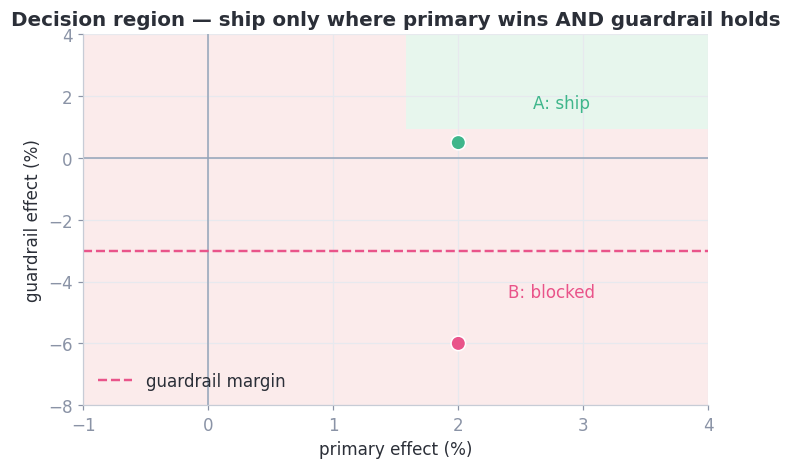

In [6]:
prim = np.linspace(-0.01, 0.04, 120)                  # primary effect
guard = np.linspace(-0.08, 0.04, 120)                 # guardrail effect
P, Gd = np.meshgrid(prim, guard)
se_p, se_g, margin = 0.008, 0.02, 0.03
ship_region = ((P - 1.96 * se_p) > 0) & ((Gd - 1.96 * se_g) > -margin)   # superiority ∧ non-inferiority
fig, ax = plt.subplots(figsize=(6.6, 4.4))
ax.contourf(P * 100, Gd * 100, ship_region, levels=[-.5, .5, 1.5], colors=["#FBEBEB", "#E7F6ED"])
ax.axvline(0, color="#94A3B8", lw=1); ax.axhline(0, color="#94A3B8", lw=1)
ax.axhline(-margin * 100, color=PINK, ls="--", lw=1.6, label="guardrail margin")
ax.scatter([2.0, 2.0], [0.5, -6.0], c=[GREEN, PINK], s=90, zorder=3, edgecolor="white")
ax.annotate("A: ship", (2.0, 0.5), (2.6, 1.6), color=GREEN)
ax.annotate("B: blocked", (2.0, -6.0), (2.4, -4.5), color=PINK)
ax.set_xlabel("primary effect (%)"); ax.set_ylabel("guardrail effect (%)")
ax.set_title("Decision region — ship only where primary wins AND guardrail holds"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

## 5. Promote → `lyra/{power,decisions}` + wire both ends of the lifecycle

Promoted: `lyra/power.py` (`required_n`, `mde`, `power_gate`, `test_and_roll_size`) and
`lyra/decisions.py` (`ship_decision`). We verify parity, then the chassis wires them in: the **DRAFT
gate** shows the SSC breakdown + MDE, and **every experiment** gets a **ship recommendation** (the
conjunction) — including one where a guardrail blocks the ship.

In [7]:
from lyra.power import required_n as lyra_required_n, mde as lyra_mde
from lyra.decisions import ship_decision

print("promoted lyra.power required_n =", lyra_required_n(p0, rel_mde, sigma2=0.0, binary=True)["n_total"],
      "  MDE at N=20000 =", round(lyra_mde(20000, p0, 0.0, binary=True)["rel_mde"], 4), "(relative)")
d = ship_decision({"ci_low": 0.012, "ci_high": 0.028, "direction": "up", "effect": 0.02},
                  [{"name": "gross margin", "ci_low": -0.09, "ci_high": -0.03, "margin": 0.03, "effect": -0.06}])
print("promoted ship_decision (B):", "SHIP" if d["ship"] else "NO SHIP —", d["reason"])

promoted lyra.power required_n = 50233   MDE at N=20000 = 0.0792 (relative)
promoted ship_decision (B): NO SHIP — blocked: gross margin regressed beyond its margin


✅ **Promoted** (covered by `tests/test_decisions.py`). The platform now sizes every design at DRAFT and
recommends ship/no-ship at every readout via the conjunction rule — the cross-cutting bookends. **Next
(`ROADMAP.md`): NB 09 — CATE** (who responds; meta-learners + causal forests).